# Baseline Demo for neural signal forecasting

In [1]:
# Build dataloader
import torch
import numpy as np
import os
from tqdm import tqdm

input_dir = './'

In [2]:
# prompt: write a function for torch dataloader

from torch.utils.data import DataLoader, Dataset, TensorDataset


def load_dataset(filename):
    """
    Load test dataset from file.

    Args:
        filename: Name of the test data file

    Returns:
        train_data: Samples to train with shape
                  (num_samples, num_timestep, num_channels, num_bands)
        test_data: Samples to test with shape
                  (num_samples, num_timestep, num_channels, num_bands)
        val_data: Samples to validate with shape
                  (num_samples, num_timestep, num_channels, num_bands)
    """
    test_file = os.path.join(input_dir, filename)
    # Open the file and load the data
    # split into train(80%), test(10%), val(10%)
    data = np.load(test_file)['arr_0']
    train_data = data[:int(len(data)*0.8)]
    test_data = data[int(len(data)*0.8):int(len(data)*0.9)]
    val_data = data[int(len(data)*0.9):]

    return train_data, test_data, val_data


def normalize(data, average=[], std=[]):
    # normalizing input to the range of [~mean - 4*std, ~mean + 4*std]
    # becasue in this dataset, the timestep is in first dimension.
    # adapt the normalization to fit this situation, compute mean and std in axis 0
    # if data.ndim == 4:
    #     n, t, c, f = data.shape
    #     data = data.reshape((n*t, -1))  # neuron input
    # if len(average) == 0:
    #     average = np.mean(data, axis=0, keepdims=True)
    #     std = np.std(data, axis=0, keepdims=True)
    # combine_max = average + 4 * std
    # combine_min = average - 4 * std
    # norm_data = 2 * (data - combine_min) / (combine_max - combine_min) - 1
    # norm_data = norm_data.reshape((n, t, c, f))
    # return norm_data, average, std
  
    n, t, c, f = data.shape
    # 重新排列以便對每個通道(C)和特徵(F)單獨做標準化
    flat_data = data.reshape(n * t, c * f) 
    
    if len(average) == 0:
        average = np.mean(flat_data, axis=0, keepdims=True) # (1, C*F)
        std = np.std(flat_data, axis=0, keepdims=True) + 1e-6
        
    combine_max = average + 4 * std
    combine_min = average - 4 * std
    
    # 進行標準化
    norm_data = 2 * (flat_data - combine_min) / (combine_max - combine_min + 1e-6) - 1
    norm_data = norm_data.reshape(n, t, c, f)
    return norm_data, average, std


class NeuroForcastDataset(Dataset):
  def __init__(self, neural_data, use_graph=False, average=[], std=[]):
    """
    neural_data: N*T*C*F (sampe size * total time steps * channel *feature dimension)
    f_window: T' the length of prediction window
    batch_size: batch size
    """
    self.data = neural_data
    self.use_graph = use_graph
    if len(average) == 0:
      self.data, self.average, self.std = normalize(self.data)
    else:
      self.data, self.average, self.std = normalize(self.data, average, std)

  def __len__(self) -> int:
    return len(self.data)

  def __getitem__(self, index):
    data = self.data[index]
    # if not self.use_graph:
    #   data = data[:, :, 0]

    data = torch.tensor(data, dtype=torch.float32)
    return data


class NFBaseModel(torch.nn.Module):
  def __init__(self, input_size=96, hidden_size=256):
    super(NFBaseModel, self).__init__()
    self.encoder = torch.nn.GRU(
        input_size=input_size, hidden_size=hidden_size, num_layers=2, batch_first=True)
    self.output_layer = torch.nn.Linear(hidden_size, input_size)

  def forward(self, x):
    output, hidden = self.encoder(x)
    output = self.output_layer(output)
    return output

  def predict(self, x):
    output, hidden = self.encoder(x)
    output = self.output_layer(output)
    return output



class Trainer():
  def __init__(self, model, train_data_loader, test_data_loader,
               val_data_loader, loss_fn, optimizer, device, scheduler=None,
               forecasting_mode='multi_step', init_steps=10,
               save_path='', ckpt_path=None,
               max_grad_norm=1.0,
               validate_every=1,
               save_best=True):
    """
    Args:
      forecasting_mode: 'one_step' or 'multi_step'
      init_steps: observed steps (default 10)
      save_path: where to save best weights (state_dict)
      ckpt_path: optional path to resume
      max_grad_norm: gradient clipping norm (anti-divergence)
      validate_every: run validation every N epochs (set 1 to run each epoch)
      save_best: save best checkpoint by validation loss
    """
    self.model = model
    self.train_data_loader = train_data_loader
    self.test_data_loader = test_data_loader
    self.val_data_loader = val_data_loader

    self.loss_fn = loss_fn
    self.optimizer = optimizer
    self.device = device
    self.scheduler = scheduler

    self.forecasting_mode = forecasting_mode
    self.init_steps = init_steps

    self.save_path = save_path
    self.ckpt_path = ckpt_path

    self.max_grad_norm = max_grad_norm
    self.validate_every = validate_every
    self.save_best = save_best
    self.best_val = float("inf")

    self.model.to(self.device)

    if ckpt_path is not None:
      self.load_model(ckpt_path)

  def prepare_data(self, data):
    # print('data',data.shape)
    # data: (B, T, C, F)
    if self.forecasting_mode == 'one_step':
      # input_data = data[:, :-1, :]
      # target_data = data[:, 1:, :]
      input_data = data[:, :-1, :, :]
      target_data = data[:, 1:, :, 0] # 只預測 feature 0 (LFP)
    elif self.forecasting_mode == 'multi_step':
      future_step = data.shape[1] - self.init_steps
      # mask future by repeating last observed step
      input_data = torch.cat([
          data[:, :self.init_steps, :,:],
          # torch.repeat_interleave(data[:, self.init_steps-1:self.init_steps, :], future_step, dim=1)
          torch.repeat_interleave(data[:, self.init_steps-1:self.init_steps, :, :], future_step, dim=1)
      ], dim=1)
      # IMPORTANT: target is future only (B,10,C)
      # target_data = data[:, self.init_steps:, :]
      target_data = data[:, self.init_steps:, :, 0]
    else:
      raise ValueError(f"Unknown forecasting_mode: {self.forecasting_mode}")
    # print('input_data',input_data.shape)
    # print('target_data',target_data.shape)
    return input_data, target_data

  def loss_function(self, prediction, target):
    if self.forecasting_mode == 'one_step':
      return self.loss_fn(prediction, target)
    # multi_step: prediction is (B,20,C), target is (B,10,C)
    return self.loss_fn(prediction[:, self.init_steps:, :], target)

  @torch.no_grad()
  def validation(self):
    self.model.eval()
    val_loss = 0.0
    pbar = tqdm(self.val_data_loader, desc="Val", leave=False)
    for batch in pbar:
      batch = batch.to(self.device)
      x, y = self.prepare_data(batch)
      out = self.model(x)
      loss = self.loss_function(out, y)

      if not torch.isfinite(loss):
        pbar.set_postfix({"val_loss": "NaN/Inf - skipped"})
        continue

      val_loss += loss.item()
      pbar.set_postfix({"val_loss": f"{val_loss / max(1, pbar.n+1):.6f}"})
    return val_loss

  def save_model(self):
    if not self.save_path:
      raise ValueError("save_path is empty. Please set save_path to save weights.")
    torch.save(self.model.state_dict(), self.save_path)

  def load_model(self, path):
    state = torch.load(path, map_location="cpu")
    self.model.load_state_dict(state)
    self.model.to(self.device)

  def train(self, num_epochs):
    for epoch in range(num_epochs):
      self.model.train()
      running_loss = 0.0

      lr = self.optimizer.param_groups[0]["lr"] if self.optimizer is not None else None
      pbar = tqdm(self.train_data_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

      for batch in pbar:
        batch = batch.to(self.device)
        x, y = self.prepare_data(batch)

        self.optimizer.zero_grad(set_to_none=True)
        out = self.model(x)
        loss = self.loss_function(out, y)

        if not torch.isfinite(loss):
          pbar.set_postfix({"train_loss": "NaN/Inf - skipped"})
          continue

        loss.backward()

        # anti-divergence (your epoch~70 explosion)
        if self.max_grad_norm is not None:
          torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)

        self.optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({
          "train_loss": f"{running_loss / max(1, pbar.n+1):.6f}",
          **({ "lr": f"{lr:.2e}" } if lr is not None else {})
        })

      # scheduler: STEP ONCE PER EPOCH
      if self.scheduler is not None:
        self.scheduler.step()
        lr = self.optimizer.param_groups[0]["lr"]

      avg_train = running_loss / max(len(self.train_data_loader), 1)

      # validate every epoch (or every N epochs)
      if (epoch % self.validate_every) == 0:
        val_loss_sum = self.validation()
        avg_val = val_loss_sum / max(len(self.val_data_loader), 1)

        if lr is not None:
          print(f"Epoch {epoch:03d} | lr={lr:.6e} | Train={avg_train:.6f} | Val={avg_val:.6f}")
        else:
          print(f"Epoch {epoch:03d} | Train={avg_train:.6f} | Val={avg_val:.6f}")

        if self.save_best and avg_val < self.best_val:
          self.best_val = avg_val
          self.save_model()
          print(f"[BEST] Saved to {self.save_path} | best_val={self.best_val:.6f}")
      else:
        if lr is not None:
          print(f"Epoch {epoch:03d} | lr={lr:.6e} | Train={avg_train:.6f}")
        else:
          print(f"Epoch {epoch:03d} | Train={avg_train:.6f}")


In [3]:
import torch
import torch.nn as nn

class _AxialBlock(nn.Module):
    """
    STNDT-style axial attention block:
      1) Time attention: for each channel, attend over time
      2) Channel attention: for each time step, attend over channels
      3) FFN
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1, ffn_mult: int = 4):
        super().__init__()
        self.time_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout)
        self.chan_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout)

        self.ln_t = nn.LayerNorm(d_model)
        self.ln_c = nn.LayerNorm(d_model)
        self.ln_f = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_mult * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_mult * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, T, C, D)
        """
        B, T, C, D = x.shape

        # --- Time attention (per channel) ---
        xt = x.permute(0, 2, 1, 3).contiguous()         # (B, C, T, D)
        xt = xt.view(B * C, T, D)                       # (B*C, T, D)
        xt_ln = self.ln_t(xt)

        # 舊版 MHA 預設輸入是 (L, N, E)，所以轉置為 (T, B*C, D)
        xt_ln = xt_ln.transpose(0, 1)

        attn_t, _ = self.time_attn(xt_ln, xt_ln, xt_ln, need_weights=False)
        # xt = xt + attn_t
        xt = xt + attn_t.transpose(0, 1) # 轉回 (B*C, T, D) 加回殘差
        xt = xt.view(B, C, T, D).permute(0, 2, 1, 3).contiguous()  # (B, T, C, D)

        # --- Channel attention (per time) ---
        xc = xt.view(B * T, C, D)                       # (B*T, C, D)
        xc_ln = self.ln_c(xc)
        attn_c, _ = self.chan_attn(xc_ln, xc_ln, xc_ln, need_weights=False)
        xc = xc + attn_c
        x2 = xc.view(B, T, C, D)

        # --- FFN ---
        x3 = self.ln_f(x2)
        x3 = x2 + self.ffn(x3)
        return x3


class NFSTNDTModel(nn.Module):
    """
    Drop-in replacement for NFBaseModel:
      - input:  (B, T, C)  (your current use_graph=False setting)
      - output: (B, T, C)
    Args keep the same names you already use:
      input_size = num_channels (C)
      hidden_size = transformer d_model
    """
    def __init__(
        self,
        input_size: int = 96,     # C (kept for API compatibility; not hard-coded into weights)
        hidden_size: int = 256,   # d_model
        n_heads: int = 8,
        n_layers: int = 6,
        dropout: float = 0.1,
        max_T: int = 20,
        max_C: int = 512,
        num_features: int = 9,
    ):
        super().__init__()
        if hidden_size % n_heads != 0:
            raise ValueError(f"hidden_size (d_model) must be divisible by n_heads. Got {hidden_size} and {n_heads}.")

        self.d_model = hidden_size
        self.max_T = max_T

        # since your current x is (B,T,C) -> per-token feature dim = 1
        # self.in_proj = nn.Linear(1, hidden_size)
        self.in_proj = nn.Linear(num_features, hidden_size)

        # positional embeddings (time + channel)
        self.time_pos = nn.Parameter(torch.zeros(1, max_T, 1, hidden_size))
        self.chan_pos_base = nn.Parameter(torch.zeros(1, 1, max_C, hidden_size))

        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            _AxialBlock(d_model=hidden_size, n_heads=n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])

        # predict feature0 only -> output (B,T,C)
        self.out_proj = nn.Linear(hidden_size, 1)

        nn.init.trunc_normal_(self.time_pos, std=0.02)
        nn.init.trunc_normal_(self.chan_pos_base, std=0.02)

    def _channel_pos(self, C: int) -> torch.Tensor:
        # base is (1,1,max_C,D). If C > max_C, repeat.
        baseC = self.chan_pos_base.shape[2]
        if C <= baseC:
            return self.chan_pos_base[:, :, :C, :]
        reps = (C + baseC - 1) // baseC
        pos = self.chan_pos_base.repeat(1, 1, reps, 1)[:, :, :C, :]
        return pos

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, T, C, F) float32
        return: (B, T, C)
        """
        # if x.dim() != 3:
        #     raise ValueError(f"Expected x with shape (B,T,C). Got {tuple(x.shape)}")

        # B, T, C = x.shape
        B, T, C, F = x.shape
        # if T > self.time_pos.shape[1]:
        #     raise ValueError(f"T={T} exceeds max_T={self.time_pos.shape[1]}. Increase max_T if needed.")

        # h = x.unsqueeze(-1)                 # (B,T,C,1)
        h = self.in_proj(x)                 # (B,T,C,D)
        h = h + self.time_pos[:, :T, :, :] + self._channel_pos(C)
        h = self.drop(h)

        for blk in self.blocks:
            h = blk(h)

        y = self.out_proj(h).squeeze(-1)    # (B,T,C)
        return y

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        return self.forward(x)


train_data shape: (560, 20, 89, 9)
test_data shape: (70, 20, 89, 9)
val_data shape: (70, 20, 89, 9)


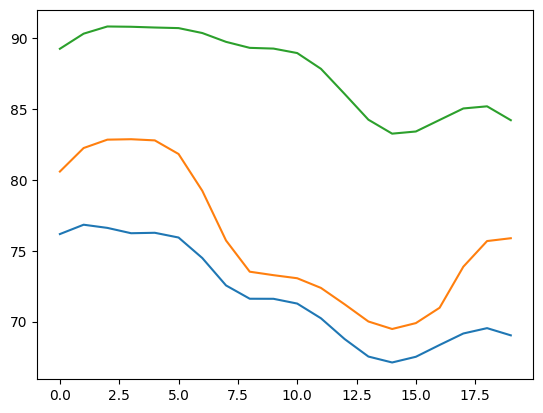

In [4]:
# parameters:
dataset_name = 'beignet'
# dataset_name = 'affi'
if dataset_name == 'beignet':
  num_channels = 89
else:
  num_channels = 239

batch_size = 4
num_epochs = 100
learning_rate = 1e-4
hidden_size = 512
input_size = num_channels

# define dataloader
train_data, test_data, val_data = load_dataset(
    f'dataset/train_data_{dataset_name}.npz')  # B * T * C * F

# print the shape of the train, test, val data
print(f'train_data shape: {train_data.shape}')
print(f'test_data shape: {test_data.shape}')
print(f'val_data shape: {val_data.shape}')

# plot test_data curve for a few channels
import matplotlib.pyplot as plt
plt.plot(test_data[0, :, 0, 1])
plt.plot(test_data[0, :, 1, 1])
plt.plot(test_data[0, :, 2, 1])
plt.show()

In [5]:
from torch.utils.data import DataLoader
import numpy as np
import torch

# --- Dataset / Dataloader ---
train_ds = NeuroForcastDataset(train_data, use_graph=False)
np.savez(f'train_data_average_std_{dataset_name}.npz', average=train_ds.average, std=train_ds.std)

test_ds = NeuroForcastDataset(test_data, use_graph=False, average=train_ds.average, std=train_ds.std)
val_ds  = NeuroForcastDataset(val_data,  use_graph=False, average=train_ds.average, std=train_ds.std)

train_data_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_data_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
val_data_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)


# --- Model ---
model = NFSTNDTModel(
    hidden_size=hidden_size,
    input_size=input_size,
    n_heads=8,
    n_layers=6,
    dropout=0.1
).to(torch.device('cuda'))

# --- Loss / Optim / Scheduler ---
loss_fn = torch.nn.MSELoss(reduction="mean")
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
lambda1 = lambda epoch: 0.95 ** (epoch // 20)   # stable decay
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)

# --- Trainer ---
save_path = f'./model_{dataset_name}.pth'  # BEST will be saved here
trainer = Trainer(
    model=model,
    train_data_loader=train_data_loader,
    test_data_loader=test_data_loader,
    val_data_loader=val_data_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=torch.device('cuda'),
    scheduler=scheduler,
    forecasting_mode='multi_step',
    init_steps=10,
    save_path=save_path,
    ckpt_path=None,
    max_grad_norm=1.0,
    validate_every=1,   # every epoch
    save_best=True
)

trainer.train(num_epochs)
print("Best val:", trainer.best_val)
print("Best weight path:", save_path)


Epoch 1/100: 100%|██████████| 140/140 [00:05<00:00, 24.94it/s, train_loss=4.618030, lr=3.00e-04]


Epoch 000 | lr=3.000000e-04 | Train=4.618030 | Val=1.223309
[BEST] Saved to ./model_beignet.pth | best_val=1.223309


Epoch 2/100: 100%|██████████| 140/140 [00:05<00:00, 27.67it/s, train_loss=0.275204, lr=3.00e-04]


Epoch 001 | lr=3.000000e-04 | Train=0.273238 | Val=0.320906
[BEST] Saved to ./model_beignet.pth | best_val=0.320906


Epoch 3/100: 100%|██████████| 140/140 [00:05<00:00, 27.68it/s, train_loss=0.102608, lr=3.00e-04]


...

Epoch 097 | lr=2.443519e-04 | Train=0.009917 | Val=0.016354


Epoch 99/100: 100%|██████████| 140/140 [00:05<00:00, 27.62it/s, train_loss=0.009742, lr=2.44e-04]


Epoch 098 | lr=2.443519e-04 | Train=0.009673 | Val=0.017219


Epoch 100/100: 100%|██████████| 140/140 [00:05<00:00, 27.79it/s, train_loss=0.009621, lr=2.44e-04]
                                                                       

Epoch 099 | lr=2.321343e-04 | Train=0.009553 | Val=0.017039
Best val: 0.015137834784885248
Best weight path: ./model_beignet.pth


[Competition-style] Future10 MSE (model, normalized): 0.015162
[Competition-style] Future10 MSE (model, raw units): 55214.587906
[Naive repeat ]    Future10 MSE (normalized): 0.025236
[Naive repeat ]    Future10 MSE (raw units): 88445.741385


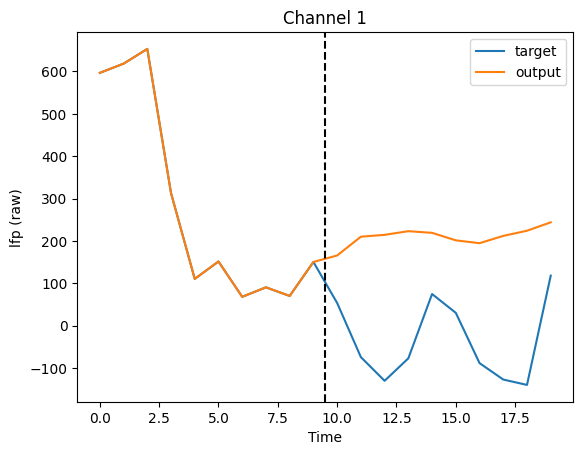

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt

INIT_STEPS = 10
DEVICE = torch.device("cuda")

# --- Load BEST model ---
model_test = NFSTNDTModel(hidden_size=hidden_size, input_size=input_size, n_heads=8, n_layers=6, dropout=0.1).to(DEVICE)
model_test.load_state_dict(torch.load(f'./model_{dataset_name}.pth', map_location="cpu"))
model_test.eval()

# --- De-normalization helpers (feature 0 only) ---
stats = np.load(f'train_data_average_std_{dataset_name}.npz')
avg_cf = stats['average']  # (1, C*F)
std_cf = stats['std']
num_feats = avg_cf.shape[1] // num_channels
avg_f0 = avg_cf.reshape(1, num_channels, num_feats)[..., 0]
std_f0 = std_cf.reshape(1, num_channels, num_feats)[..., 0]
combine_max = avg_f0 + 4 * std_f0
combine_min = avg_f0 - 4 * std_f0

def denorm_feature0(x, channel_idx=None):
    x_np = x.detach().cpu().numpy() if torch.is_tensor(x) else x
    if x_np.shape[-1] == num_channels:
        return ((x_np + 1) / 2) * (combine_max - combine_min) + combine_min
    if channel_idx is None:
        raise ValueError("channel_idx required for single-channel inputs")
    cmax = combine_max[..., channel_idx]
    cmin = combine_min[..., channel_idx]
    return ((x_np + 1) / 2) * (cmax - cmin) + cmin

def prepare_input_masked(data, init_steps=INIT_STEPS):
    # data: (B,20,C,F)
    future = data.shape[1] - init_steps
    x_in = torch.cat([
        data[:, :init_steps, :, :],
        data[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)
    y_future = data[:, init_steps:, :, 0]  # (B,10,C) feature0 target
    return x_in, y_future

@torch.no_grad()
def eval_future_mse(model, loader, device=DEVICE, init_steps=INIT_STEPS):
    preds, tgts = [], []
    for batch in loader:
        batch = batch.to(device)  # (B,20,C,F)
        x_in, y_future = prepare_input_masked(batch, init_steps=init_steps)

        y_hat_full = model(x_in)  # (B,20,C)

        # enforce competition definition: first 10 steps are the given values
        y_hat_full[:, :init_steps, :] = batch[:, :init_steps, :, 0]

        y_hat_future = y_hat_full[:, init_steps:, :]  # (B,10,C)

        preds.append(y_hat_future.detach().cpu())
        tgts.append(y_future.detach().cpu())

    preds = torch.cat(preds, dim=0)
    tgts  = torch.cat(tgts,  dim=0)
    mse = torch.mean((tgts - preds) ** 2).item()
    return mse, preds.numpy(), tgts.numpy()

@torch.no_grad()
def naive_repeat_baseline_mse(loader, device=DEVICE, init_steps=INIT_STEPS):
    mses = []
    for batch in loader:
        batch = batch.to(device)  # (B,20,C,F)
        y_true = batch[:, init_steps:, :, 0]
        last = batch[:, init_steps-1:init_steps, :, 0].repeat(1, y_true.shape[1], 1)
        mses.append(torch.mean((y_true - last) ** 2).item())
    return float(sum(mses) / max(len(mses), 1))

@torch.no_grad()
def naive_repeat_baseline_mse_raw(loader, device=DEVICE, init_steps=INIT_STEPS):
    mses = []
    for batch in loader:
        batch = batch.to(device)  # (B,20,C,F)
        y_true = batch[:, init_steps:, :, 0]
        last = batch[:, init_steps-1:init_steps, :, 0].repeat(1, y_true.shape[1], 1)
        y_true_raw = denorm_feature0(y_true)
        last_raw = denorm_feature0(last)
        mses.append(float(np.mean((y_true_raw - last_raw) ** 2)))
    return float(sum(mses) / max(len(mses), 1))

mse_model_norm, pred_future_norm, tgt_future_norm = eval_future_mse(model_test, test_data_loader, DEVICE, INIT_STEPS)
mse_naive_norm = naive_repeat_baseline_mse(test_data_loader, DEVICE, INIT_STEPS)
mse_naive_raw = naive_repeat_baseline_mse_raw(test_data_loader, DEVICE, INIT_STEPS)

# inverse back to original units (feature 0)
pred_future = denorm_feature0(pred_future_norm)
tgt_future = denorm_feature0(tgt_future_norm)
mse_model_raw = float(np.mean((tgt_future - pred_future) ** 2))

print(f"[Competition-style] Future10 MSE (model, normalized): {mse_model_norm:.6f}")
print(f"[Competition-style] Future10 MSE (model, raw units): {mse_model_raw:.6f}")
print(f"[Naive repeat ]    Future10 MSE (normalized): {mse_naive_norm:.6f}")
print(f"[Naive repeat ]    Future10 MSE (raw units): {mse_naive_raw:.6f}")

# --- Plot one example (full 20 steps) for chosen channel ---

@torch.no_grad()
def plot_channel(model, data_loader, channel_idx=1, device=torch.device("cuda"), init_steps=10, denorm=True):
    model.eval()
    batch = next(iter(data_loader)).to(device)   # (B,20,C,F)

    # build masked input
    future = batch.shape[1] - init_steps
    x_in = torch.cat([
        batch[:, :init_steps, :, :],
        batch[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)

    # model output
    y_hat = model(x_in)  # (B,20,C)

    # enforce competition rule: first 10 steps are given
    y_hat[:, :init_steps, :] = batch[:, :init_steps, :, 0]

    # pick one sample
    y_true = batch[0, :, channel_idx, 0]
    y_pred = y_hat[0, :, channel_idx]

    if denorm:
        y_true = denorm_feature0(y_true, channel_idx=channel_idx)
        y_pred = denorm_feature0(y_pred, channel_idx=channel_idx)
        ylabel = "lfp (raw)"
    else:
        y_true = y_true.detach().cpu().numpy()
        y_pred = y_pred.detach().cpu().numpy()
        ylabel = "lfp (normalized)"

    plt.figure()
    plt.plot(y_true, label="target")
    plt.plot(y_pred, label="output")
    plt.axvline(x=init_steps-0.5, color="black", linestyle="--")
    plt.title(f"Channel {channel_idx}")
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


plot_channel(model_test, test_data_loader, channel_idx=1)